# JSS-SLR Mapping Study Visualization

This notebook creates publication-quality visualizations for the SLR:
- 2 Histograms (publication frequency, architectural style distribution)
- 7 Systematic Maps (4x 2D, 3x 3D)
- Multiple color palette options
- Direct PDF export with preview

**Data**: 51 papers from systematic literature review (non-contiguous IDs: 1-54, excluding 23, 27, 41)

## 1. Setup and Configuration

In [219]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.options.display.max_rows = 50
pd.options.display.max_columns = 50

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [269]:
# Configure matplotlib for LaTeX output
USE_LATEX = False  # Set to False to disable LaTeX rendering (for PDF export with preview)

if USE_LATEX:
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        'font.family': 'serif',
        'text.usetex': True,
        'pgf.rcfonts': False,
        'font.size': 11,
        'axes.labelsize': 11,
        'axes.titlesize': 11,
        'legend.fontsize': 11,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
    })
    print("✓ LaTeX rendering enabled (PGF backend)")
else:
    sns.set(style="whitegrid", context="paper", font_scale=0.9)
    print("✓ Standard rendering enabled")

✓ Standard rendering enabled


In [270]:
# Color palette selection (choose one: 'Set2', 'tab10', 'muted', 'steel_warm')
PALETTE_CHOICE = 'steel_warm'  # Change this to switch color schemes

# Define color palettes
PALETTES = {
    'Set2': {
        'name': 'Set2 (high contrast, distinct colors)',
        'cmap': 'Set2',
        'colors': sns.color_palette('Set2', n_colors=10)
    },
    'tab10': {
        'name': 'Tableau 10 (vibrant, professional)',
        'cmap': 'tab10',
        'colors': sns.color_palette('tab10', n_colors=10)
    },
    'crest': {
        'name': 'crest',
        'cmap': 'crest',
        'colors': sns.color_palette('crest', n_colors=5)
    },
    'muted': {
        'name': 'Muted (subdued qualitative, publication-friendly)',
        'cmap': 'muted',
        'colors': sns.color_palette('muted', n_colors=10)
    },
    'steel_warm': {
        'name': 'Steel-Warm (lightsteelblue + sage green + warm sand)',
        'cmap': None,
        'colors': ['#B0C4DE', '#C5D8A4', '#F2C98A']
    },
}

current_palette = PALETTES[PALETTE_CHOICE]
print(f"✓ Using palette: {current_palette['name']}")


✓ Using palette: Steel-Warm (lightsteelblue + sage green + warm sand)


## 2. Data Loading and Category Definitions

In [ ]:
# Load data
data_path = Path('../data/JSS-SLR/full_table_for_analysis.csv')
df = pd.read_csv(data_path, sep=';', encoding='latin-1')  # Changed from utf-8

print(f"✓ Loaded {len(df)} papers")
print(f"  Columns: {len(df.columns)}")
print(f"  Years: {df['Year'].min()} - {df['Year'].max()}")

# Verify expected paper count
assert len(df) == 51, f"Expected 51 papers, got {len(df)}"
print("✓ Paper count verified (51 papers)")

✓ Loaded 51 papers
  Columns: 62
  Years: 2020 - 2026
✓ Paper count verified (51 papers)


In [341]:
# Define category mappings (column names to categories)
CATEGORIES = {
    'Research Type': ['Evaluation', 'Solution (RTF)', 'Philosophical'],
    'Contribution Type': ['Guideline', 'Tool', 'Framework', 'Solution (CTF)', 'Technique'],
    'Architectural Style': ['Component-based', 'SOA/Microservice', 'Client-Server Architecture', 
                           'Data-Centric Architecture', 'Distributed Architecture', 'Three-Tier Architecture'],
    'Runtime': ['Interpreter', 'Compiler', 'ONNX'],
    'Monitoring Metrics': ['Concept/Data Drift', 'Model Accuracy', 'RAM', 'CPU', 
                          'Energy Consumption', 'Storage', 'Computional Latency'],
    'Model Training': ['Decentral Training', 'Central Training', 'Hybrid Training'],
    'Model Management': ['Model Versioning', 'Experiment Tracking', 'Data Versioning'],
    'Model Learning': ['Online Learning', 'Offline Learning', 'Lifelong Learning'],
    'Model Optimization': ['Sparsification', 'Code Generation', 'Pruning', 'Adaptive Computation', 'Quantization', 
                          'Knowledge Distillation', 'Test-Time Adaptation', 'Feature Caching', 
                          'Network/Model partitioning'],
    'CI/CD': ['Rollback', 'Automated Deployment', 'Automated Testing', 'Full Model Update', 
             'Partial Model Update', 'Containization' , 'Hardware Emulation'],
    'Use Case Category': ['Sensor', 'Audio', 'Computer Vision'],
    'Hardware Category': ['Ultra Low-Power', 'Mid-Range', 'High-Performance', 
                         'Single-Board Computer', 'External Accelerator']
}

# Display name overrides (maps column names to chart labels)
# \u00a0 = non-breaking space — wrap_label will never split at this position
DISPLAY_NAMES = {
    'Solution (RTF)': 'Solution',
    'Solution (CTF)': 'Solution',
    'Full Model Update': 'Full\u00a0Model Update',
    'Sparsification' : 'Sparsi-fication',
    'Code Generation': 'Model\u00a0Format Conversion',
    'Decentral Training': 'Decentralized Training',
    'Containization': 'Container-ization'
}

# Histograms don't wrap labels via wrap_label(), so hyphenation-only overrides are excluded here
HISTOGRAM_DISPLAY_NAMES = {k: v for k, v in DISPLAY_NAMES.items() if k not in ('Sparsification', 'Containization')}
HISTOGRAM_DISPLAY_NAMES['Containization'] = 'Containerization'

# Verify all columns exist
missing_cols = []
for cat_name, cols in CATEGORIES.items():
    for col in cols:
        if col not in df.columns:
            missing_cols.append(f"{cat_name}: {col}")

if missing_cols:
    print("⚠ Missing columns:")
    for mc in missing_cols:
        print(f"  - {mc}")
else:
    print("✓ All category columns verified")

print(f"\nCategories defined: {len(CATEGORIES)}")

for cat_name, cols in CATEGORIES.items():
    print(f"  - {cat_name}: {len(cols)} elements")

✓ All category columns verified

Categories defined: 12
  - Research Type: 3 elements
  - Contribution Type: 5 elements
  - Architectural Style: 6 elements
  - Runtime: 3 elements
  - Monitoring Metrics: 7 elements
  - Model Training: 3 elements
  - Model Management: 3 elements
  - Model Learning: 3 elements
  - Model Optimization: 9 elements
  - CI/CD: 7 elements
  - Use Case Category: 3 elements
  - Hardware Category: 5 elements


## 3. Helper Functions

In [342]:
def create_category_pivot(df, x_category, y_category):
    """
    Create pivot table for cross-tabulation of two categories.
    Returns: pivot table with intersection counts
    """
    x_cols = CATEGORIES[x_category]
    y_cols = CATEGORIES[y_category]
    
    # Create cross-tabulation matrix
    pivot = pd.DataFrame(index=y_cols, columns=x_cols, dtype=int)
    
    for y_col in y_cols:
        for x_col in x_cols:
            # Count papers where both flags are 1
            count = ((df[x_col] == 1) & (df[y_col] == 1)).sum()
            pivot.loc[y_col, x_col] = count
    
    return pivot


def calculate_category_stats(df, category_name):
    """
    Calculate counts and percentages for each element in a category.
    Returns: DataFrame with 'element', 'count', 'percentage'
    """
    cols = CATEGORIES[category_name]
    stats = []
    
    for col in cols:
        count = (df[col] == 1).sum()
        stats.append({'element': col, 'count': count})
    
    stats_df = pd.DataFrame(stats)
    total = stats_df['count'].sum()
    stats_df['percentage'] = (stats_df['count'] / total * 100).round(2) if total > 0 else 0
    
    return stats_df


def bubble_size_from_count(count, scale_factor=25):
    """
    Calculate bubble size using ln-scaling (PowerPoint formula).
    ln(count) = diameter in centimeters.
    Convert to matplotlib scatter area (s parameter = area in points²).
    """
    if count == 0:
        return 0
    if count == 1:
        return (0.5 * scale_factor) ** 2  # Minimum size for count=1
    diameter_cm = np.log(count)  # ln(count) gives diameter in cm
    # Convert diameter to area for matplotlib scatter
    # scale_factor converts cm to points for visibility
    return (diameter_cm * scale_factor) ** 2


def wrap_label(text, max_len=13):
    """
    Break long labels into multiple lines (same logic as histograms).
    Non-breaking spaces (\\u00a0) are preserved and never used as break points.
    """
    if len(text) <= max_len:
        return text
    # Split only on regular spaces so non-breaking spaces are preserved
    words = text.split(' ')
    if len(words) > 1:
        mid = len(words) // 2
        return ' '.join(words[:mid]) + '\n' + ' '.join(words[mid:])
    elif '-' in text:
        return text.replace('-', '-\n', 1)
    elif '/' in text:
        return text.replace('/', '/\n', 1)
    return text


def escape_latex(text):
    """
    Escape special LaTeX characters in text.
    """
    if not USE_LATEX:
        return text
    
    replacements = {
        '%': r'\%',
        '&': r'\&',
        '#': r'\#',
        '_': r'\_',
        '/': r'/',  # Keep slash as is
    }
    
    for char, replacement in replacements.items():
        text = text.replace(char, replacement)
    return text


print("✓ Helper functions defined")


✓ Helper functions defined


## 4. Histogram 1: Publication Frequency by Year and Type

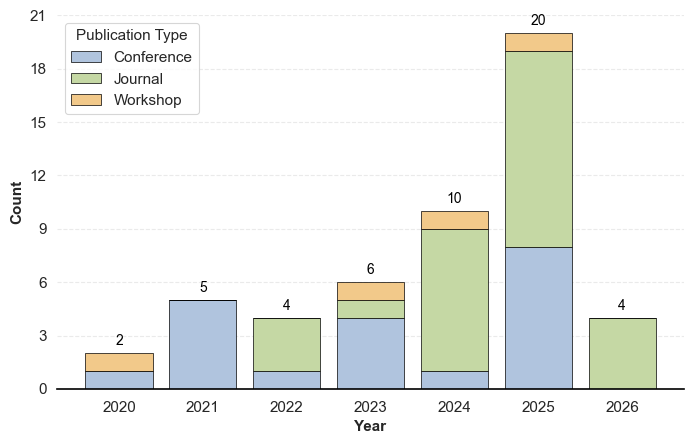

✓ Histogram 1 created


In [343]:
# Prepare data for stacked bar chart
year_type_counts = df.groupby(['Year', 'Publication Type']).size().reset_index(name='Count')
years = sorted(year_type_counts['Year'].unique())
pub_types = sorted(year_type_counts['Publication Type'].unique())

# Create data matrix for stacked bars
data_matrix = np.zeros((len(pub_types), len(years)))
for i, pub_type in enumerate(pub_types):
    for j, year in enumerate(years):
        count = year_type_counts[
            (year_type_counts['Year'] == year) & 
            (year_type_counts['Publication Type'] == pub_type)
        ]['Count'].values
        data_matrix[i, j] = count[0] if len(count) > 0 else 0

# Create figure (optimized for ACM journal single-column)
fig, ax = plt.subplots(figsize=(7, 4.5))

# Get colors from palette
colors = current_palette['colors'][:len(pub_types)]

# Plot stacked bars
bottom = np.zeros(len(years))
for i, pub_type in enumerate(pub_types):
    ax.bar(years, data_matrix[i], bottom=bottom, label=escape_latex(pub_type),
           color=colors[i], edgecolor='black', linewidth=0.5)
    bottom += data_matrix[i]

# Add year totals at the top of each bar
for j, year in enumerate(years):
    total = int(bottom[j])
    ax.text(year, bottom[j] + 0.3, 
            str(total), 
            ha='center', va='bottom', 
            fontsize=10, color='black')

# Formatting
ax.set_xlabel('Year', fontweight='bold', fontsize=11)
ax.set_ylabel('Count', fontweight='bold', fontsize=11)
ax.legend(title=escape_latex('Publication Type'), frameon=True, loc='upper left', fontsize=11, title_fontsize=11)
ax.tick_params(axis='both', labelsize=11)

# Y-axis: only integer values
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.grid(False)  # Disable all grid lines first
ax.grid(True, axis='y', alpha=0.4, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

# Remove all spines except bottom (x-axis)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['bottom'].set_color('black')

# Y-axis ticks: small black markers
ax.tick_params(axis='y', labelsize=11, length=4, color='black', width=1)

plt.tight_layout()
plt.show()

print("✓ Histogram 1 created")

## 5. Histogram 2: Architectural Style Frequency Distribution

✓ Histogram 2 created


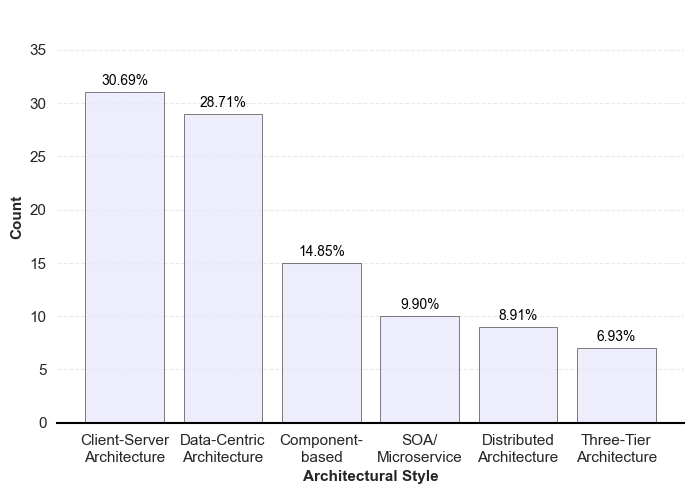

In [344]:
# Calculate architectural style frequencies
arch_stats = calculate_category_stats(df, 'Architectural Style')
arch_stats = arch_stats.sort_values('count', ascending=False)

# Create figure (single y-axis: Count)
fig, ax1 = plt.subplots(figsize=(7, 5))

# Primary axis: Count (bars)
x_pos = np.arange(len(arch_stats))
bars = ax1.bar(x_pos, arch_stats['count'], color='lavender', alpha=0.7,
               edgecolor='black', linewidth=0.5, label='Count')
ax1.set_xlabel('Architectural Style', fontweight='bold', fontsize=11)
ax1.set_ylabel('Count', fontweight='bold', fontsize=11)
ax1.set_xticks(x_pos)

# Create multi-line labels for x-axis
x_labels = []
for elem in arch_stats['element']:
    escaped = escape_latex(DISPLAY_NAMES.get(elem, elem))
    if len(escaped) > 13:
        words = escaped.split()
        if len(words) > 1:
            mid = len(words) // 2
            label = ' '.join(words[:mid]) + '\n' + ' '.join(words[mid:])
        elif '-' in escaped:
            label = escaped.replace('-', '-\n', 1)
        elif '/' in escaped:
            label = escaped.replace('/', '/\n', 1)
        else:
            label = escaped
    else:
        label = escaped
    x_labels.append(label)

ax1.set_xticklabels(x_labels, rotation=0, ha='center', fontsize=11)
ax1.tick_params(axis='y', labelsize=11, length=4, color='black', width=1)
ax1.grid(False)
ax1.grid(True, axis='y', alpha=0.4, linestyle='--', linewidth=0.8)
ax1.set_axisbelow(True)

# Add headroom for percentage labels above bars
ax1.set_ylim(0, arch_stats['count'].max() * 1.25)

# Annotate each bar with its percentage value
pct_sign = r'\%' if USE_LATEX else '%'
for bar, pct in zip(bars, arch_stats['percentage']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + ax1.get_ylim()[1] * 0.01,
        f"{pct:.2f}{pct_sign}",
        ha='center', va='bottom', fontsize=10, color='black'
    )

# Remove all spines except bottom (x-axis)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_linewidth(1.5)
ax1.spines['bottom'].set_color('black')

print("✓ Histogram 2 created")
plt.tight_layout()
plt.show()


## 5.2. Histogram 3: Architectural CI/CD tactic Frequency Distribution

✓ Histogram 4 created


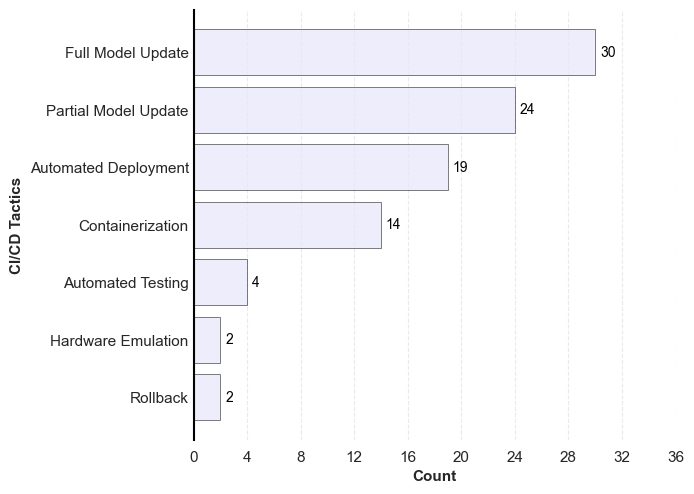

In [345]:

# Calculate model optimization frequencies
arch_stats = calculate_category_stats(df, 'CI/CD')
arch_stats = arch_stats.sort_values('count', ascending=True)  # ascending for barh (top = highest)

# Create figure (horizontal bar chart)
fig, ax1 = plt.subplots(figsize=(7, 5))

# Horizontal bars
y_pos = np.arange(len(arch_stats))
bars = ax1.barh(y_pos, arch_stats['count'], color='lavender', alpha=0.7,
                edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Count', fontweight='bold', fontsize=11)
ax1.set_ylabel('CI/CD Tactics', fontweight='bold', fontsize=11)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([HISTOGRAM_DISPLAY_NAMES.get(elem, elem) for elem in arch_stats['element']], fontsize=11)

ax1.tick_params(axis='x', labelsize=11, length=4, color='black', width=1)
ax1.tick_params(axis='y', labelsize=11, length=0)
ax1.grid(False)
ax1.grid(True, axis='x', alpha=0.4, linestyle='--', linewidth=0.8)
ax1.set_axisbelow(True)

# X-axis: only integer values
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Add headroom for count labels at end of bars
ax1.set_xlim(0, arch_stats['count'].max() * 1.2)

# Annotate each bar with its count value
for bar, cnt in zip(bars, arch_stats['count']):
    ax1.text(
        bar.get_width() + ax1.get_xlim()[1] * 0.01,
        bar.get_y() + bar.get_height() / 2,
        str(int(cnt)),
        ha='left', va='center', fontsize=10, color='black'
    )

# Remove all spines except left (y-axis)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['left'].set_linewidth(1.5)
ax1.spines['left'].set_color('black')
ax1.spines['bottom'].set_visible(False)

print("✓ Histogram 4 created")
plt.tight_layout()
plt.show()


## 5.2. Histogram 4: Architectural Optimization tactic Frequency Distribution

✓ Histogram 4 created


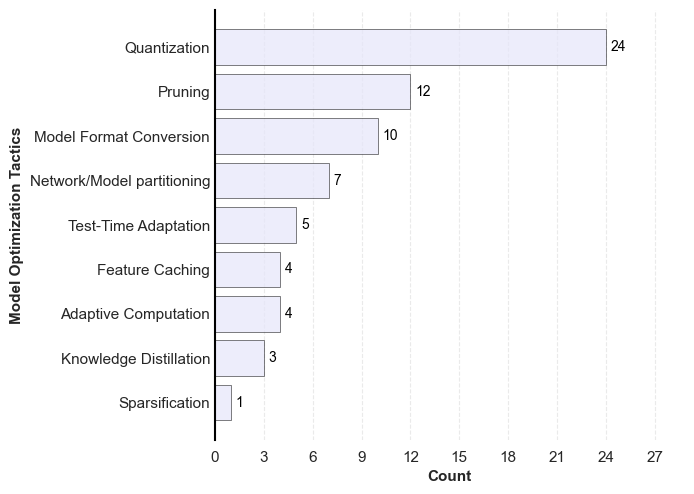

In [346]:

# Calculate model optimization frequencies
arch_stats = calculate_category_stats(df, 'Model Optimization')
arch_stats = arch_stats.sort_values('count', ascending=True)  # ascending for barh (top = highest)

# Create figure (horizontal bar chart)
fig, ax1 = plt.subplots(figsize=(7, 5))

# Horizontal bars
y_pos = np.arange(len(arch_stats))
bars = ax1.barh(y_pos, arch_stats['count'], color='lavender', alpha=0.7,
                edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Count', fontweight='bold', fontsize=11)
ax1.set_ylabel('Model Optimization Tactics', fontweight='bold', fontsize=11)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([HISTOGRAM_DISPLAY_NAMES.get(elem, elem) for elem in arch_stats['element']], fontsize=11)

ax1.tick_params(axis='x', labelsize=11, length=4, color='black', width=1)
ax1.tick_params(axis='y', labelsize=11, length=0)
ax1.grid(False)
ax1.grid(True, axis='x', alpha=0.4, linestyle='--', linewidth=0.8)
ax1.set_axisbelow(True)

# X-axis: only integer values
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Add headroom for count labels at end of bars
ax1.set_xlim(0, arch_stats['count'].max() * 1.2)

# Annotate each bar with its count value
for bar, cnt in zip(bars, arch_stats['count']):
    ax1.text(
        bar.get_width() + ax1.get_xlim()[1] * 0.01,
        bar.get_y() + bar.get_height() / 2,
        str(int(cnt)),
        ha='left', va='center', fontsize=10, color='black'
    )

# Remove all spines except left (y-axis)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['left'].set_linewidth(1.5)
ax1.spines['left'].set_color('black')
ax1.spines['bottom'].set_visible(False)

print("✓ Histogram 4 created")
plt.tight_layout()
plt.show()


## 6. 2D Systematic Maps - Helper Function

In [347]:
def create_2d_systematic_map(df, x_category, y_category, title, figsize=(7, 5.5),
                             wrap_x=True, wrap_y=True, wrap_max_len=13):
    """
    Create a 2D systematic map with bubbles showing intersections.
    Optimized for ACM journal single-column layout.
    """
    pct_sign = r'\%' if USE_LATEX else '%'

    def maybe_wrap_x(text):
        if wrap_x:
            return wrap_label(text, max_len=wrap_max_len)
        return text

    def maybe_wrap_y(text):
        if wrap_y:
            return wrap_label(text, max_len=wrap_max_len)
        return text

    # Get pivot table
    pivot = create_category_pivot(df, x_category, y_category)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Get dimensions
    x_labels = CATEGORIES[x_category]
    y_labels = CATEGORIES[y_category]
    n_x = len(x_labels)
    n_y = len(y_labels)
    
    # Calculate sums from pivot table (actual bubble counts)
    total_count = pivot.sum().sum()
    x_sums = {col: pivot[col].sum() for col in x_labels}
    y_sums = {row: pivot.loc[row].sum() for row in y_labels}
    
    # Plot bubbles
    for i, x_col in enumerate(x_labels):
        for j, y_col in enumerate(y_labels):
            count = pivot.loc[y_col, x_col]
            if count > 0:
                size = bubble_size_from_count(count)
                ax.scatter(i, j, s=size, alpha=1, 
                          color='lightsteelblue', 
                          edgecolor='black', linewidth=1)
                # Add count label (integer)
                ax.text(i, j, str(int(count)), ha='center', va='center', 
                       fontsize=11, fontweight='bold')
    
    # Format x-axis (bottom)
    ax.set_xlim(-0.5, n_x - 0.5)
    ax.set_xticks(range(n_x))
    # Create x-axis labels with stats from pivot sums
    x_tick_labels = []
    for elem in x_labels:
        n = int(x_sums[elem])
        pct = (n / total_count * 100) if total_count > 0 else 0
        display = maybe_wrap_x(DISPLAY_NAMES.get(elem, elem))
        label = f"{escape_latex(display)}\nn={n}\n({pct:.2f}{pct_sign})"
        x_tick_labels.append(label)
    
    ax.set_xticklabels(x_tick_labels, rotation=0, ha='center', fontsize=11)
    ax.set_xlabel(escape_latex(x_category), fontsize=11, labelpad=10, fontweight='bold')
    
    # Format y-axis (left)
    ax.set_ylim(-0.5, n_y - 0.5)
    ax.set_yticks(range(n_y))
    # Create Y-axis labels with stats from pivot sums
    y_tick_labels = []
    for elem in y_labels:
        n = int(y_sums[elem])
        pct = (n / total_count * 100) if total_count > 0 else 0
        display = maybe_wrap_y(DISPLAY_NAMES.get(elem, elem))
        label = f"{escape_latex(display)}\nn={n}\n({pct:.2f}{pct_sign})"
        y_tick_labels.append(label)
    
    ax.set_yticklabels(y_tick_labels, rotation=90, fontsize=11, va='center', ha='center')
    ax.set_ylabel(escape_latex(y_category), fontsize=11, labelpad=10, rotation=90, va='center', fontweight='bold')
    
    # Add dashed gray gridlines in background
    ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8, color='gray')
    ax.set_axisbelow(True)
    
    # Show only bottom and left spines (axes) - solid black
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['left'].set_color('black')
    ax.spines['left'].set_linestyle('-')
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linestyle('-')
    
    # Add ticks like in histograms
    ax.tick_params(axis='x', length=4, color='black', width=1, labelsize=11, bottom=True)
    ax.tick_params(axis='y', length=4, color='black', width=1, labelsize=11, left=True, pad=20)

    plt.tight_layout()
    print("✓ 2D systematic map function defined")

    return fig, ax


## 7. Map 1 (2D): Research Type vs Contribution Type

✓ 2D systematic map function defined


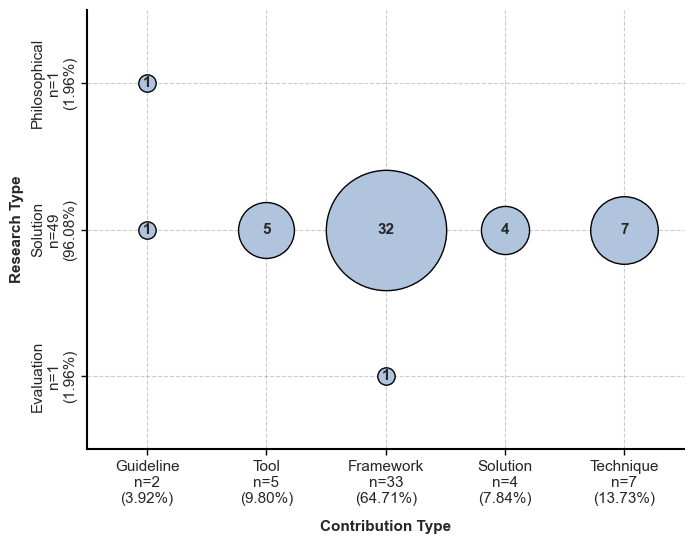

✓ Map 1 created


In [348]:
fig, ax = create_2d_systematic_map(
    df, 
    'Contribution Type', 
    'Research Type',
    'Classification Overview: Research Type vs Contribution Type'
)
plt.show()
print("✓ Map 1 created")

## 8. Map 2 (2D): Model Learning vs Model Training

✓ 2D systematic map function defined


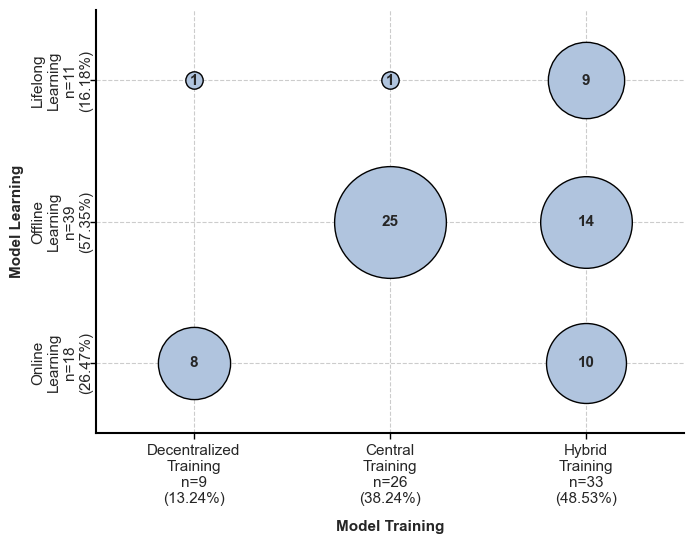

✓ Map 2 created


In [349]:
fig, ax = create_2d_systematic_map(
    df,
    'Model Training',
    'Model Learning',
    'Systematic Map: Model Learning vs Model Training'
)
plt.show()
print("✓ Map 2 created")

## 9. Map 3 (2D): Use Case Category vs Hardware Category

✓ 2D systematic map function defined


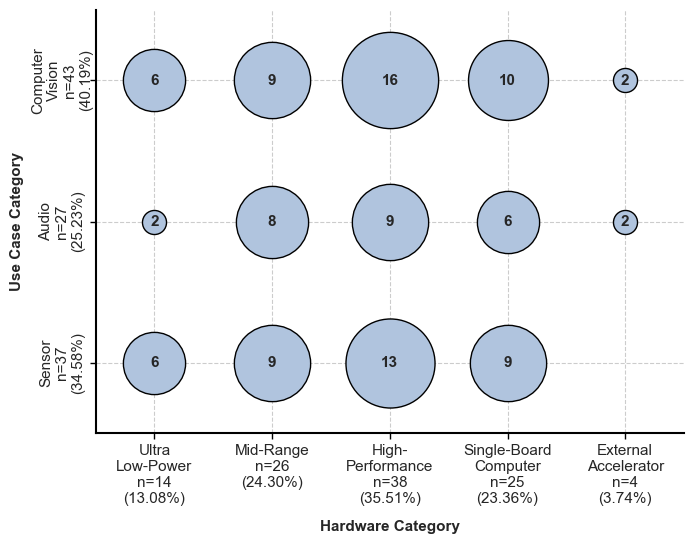

✓ Map 3 created


In [350]:
fig, ax = create_2d_systematic_map(
    df,
    'Hardware Category',
    'Use Case Category',
    'Systematic Map: Use Case vs Hardware Category'
)
plt.show()
print("✓ Map 3 created")

## 10. 3D Systematic Maps - Helper Function

In [351]:
import matplotlib.transforms as mtransforms

def create_3d_systematic_map(df, x_left_category, x_right_category, y_category,
                             title, figsize=(14, 8),
                             wrap_x=True, wrap_y=True, wrap_max_len=13,
                             x_group_label_pad=60):
    # ── ADJUST: figsize=(width, height) — increase height for more Y-axis row spacing ──
    #            e.g. 8 = compact, 12 = spread out
    # ── wrap_x: True/False — whether to line-break long X-axis category names ──
    # ── wrap_y: True/False — whether to line-break long Y-axis category names ──
    # ── wrap_max_len: int — character threshold above which wrapping is applied ──
    # ── x_group_label_pad: int — distance in points between X tick labels and group label ──
    #            figsize-independent; increase if label overlaps tick text (e.g. 55, 65)
    """
    Create a 3D systematic map with bubbles on both sides.
    - X-left  → bubbles from pivot(x_left × y)
    - X-right → bubbles from pivot(x_right × y)
    - Y-axis labels: LEFT (from left pivot), RIGHT (from right pivot)
    - Y-axis title: above the central separator line
    """
    pct_sign = r'\%' if USE_LATEX else '%'

    def maybe_wrap_x(text):
        if wrap_x:
            return wrap_label(text, max_len=wrap_max_len)
        return text

    def maybe_wrap_y(text):
        if wrap_y:
            return wrap_label(text, max_len=wrap_max_len)
        return text

    pivot_left  = create_category_pivot(df, x_left_category,  y_category)
    pivot_right = create_category_pivot(df, x_right_category, y_category)

    fig, ax = plt.subplots(figsize=figsize)

    x_left_labels  = CATEGORIES[x_left_category]
    x_right_labels = CATEGORIES[x_right_category]
    y_labels       = CATEGORIES[y_category]

    n_x_left  = len(x_left_labels)
    n_x_right = len(x_right_labels)
    n_y       = len(y_labels)
    total_x   = n_x_left + n_x_right
    sep_x     = n_x_left - 0.5

    total_left  = pivot_left.sum().sum()
    total_right = pivot_right.sum().sum()
    x_left_sums  = {col: pivot_left[col].sum()   for col in x_left_labels}
    x_right_sums = {col: pivot_right[col].sum()  for col in x_right_labels}
    y_sums_left  = {row: pivot_left.loc[row].sum()  for row in y_labels}
    y_sums_right = {row: pivot_right.loc[row].sum() for row in y_labels}

    # ── Bubbles: LEFT (x_left × y) ──
    for i, x_col in enumerate(x_left_labels):
        for j, y_col in enumerate(y_labels):
            count = pivot_left.loc[y_col, x_col]
            if count > 0:
                size = bubble_size_from_count(count)
                ax.scatter(i, j, s=size, alpha=1.0,
                           color='lightsteelblue', edgecolor='black', linewidth=1)
                ax.text(i, j, str(int(count)), ha='center', va='center',
                        fontsize=11, fontweight='bold')

    # ── Bubbles: RIGHT (x_right × y) ──
    for i, x_col in enumerate(x_right_labels):
        for j, y_col in enumerate(y_labels):
            count = pivot_right.loc[y_col, x_col]
            if count > 0:
                size = bubble_size_from_count(count)
                x_pos = n_x_left + i
                ax.scatter(x_pos, j, s=size, alpha=1.0,
                           color='lightsteelblue', edgecolor='black', linewidth=1)
                ax.text(x_pos, j, str(int(count)), ha='center', va='center',
                        fontsize=11, fontweight='bold')

    # ── Axes limits: exact bubble area so spines/grid don't overshoot ──
    ax.set_xlim(-0.5, total_x - 0.5)
    ax.set_ylim(-0.5, n_y - 0.5)

    # ── Separator: black line spanning exact bubble area, with ticks ──
    ax.plot([sep_x, sep_x], [-0.5, n_y - 0.5],
            color='black', linestyle='-', linewidth=1.5, zorder=5)
    tick_half = 0.1
    for j in range(n_y):
        ax.plot([sep_x - tick_half, sep_x + tick_half], [j, j],
                color='black', linewidth=1.0, zorder=6)

    # ── Y-axis title: above separator using blended transform (data-x, axes-y) ──
    title_trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(sep_x, 1.02, escape_latex(y_category),
            ha='center', va='bottom', fontsize=11, fontweight='bold',
            transform=title_trans, clip_on=False)

    # ── X-axis tick labels ──
    x_ticks = list(range(n_x_left)) + [n_x_left + i for i in range(n_x_right)]
    ax.set_xticks(x_ticks)

    x_left_tick_labels = []
    for elem in x_left_labels:
        n   = int(x_left_sums[elem])
        pct = (n / total_left * 100) if total_left > 0 else 0
        display = maybe_wrap_x(DISPLAY_NAMES.get(elem, elem))
        x_left_tick_labels.append(f"{escape_latex(display)}\nn={n}\n({pct:.2f}{pct_sign})")

    x_right_tick_labels = []
    for elem in x_right_labels:
        n   = int(x_right_sums[elem])
        pct = (n / total_right * 100) if total_right > 0 else 0
        display = maybe_wrap_x(DISPLAY_NAMES.get(elem, elem))
        x_right_tick_labels.append(f"{escape_latex(display)}\nn={n}\n({pct:.2f}{pct_sign})")

    ax.set_xticklabels(x_left_tick_labels + x_right_tick_labels,
                       rotation=0, ha='center', fontsize=11)

    # ── X-axis group labels: fixed point offset below x-axis (figsize-independent) ──
    x_label_trans = mtransforms.offset_copy(
        ax.get_xaxis_transform(), fig=fig, x=0, y=-x_group_label_pad, units='points')
    left_center  = (n_x_left - 1) / 2
    right_center = n_x_left + (n_x_right - 1) / 2
    ax.text(left_center,  0, escape_latex(x_left_category),
            ha='center', va='top', fontsize=11, fontweight='bold',
            transform=x_label_trans, clip_on=False)
    ax.text(right_center, 0, escape_latex(x_right_category),
            ha='center', va='top', fontsize=11, fontweight='bold',
            transform=x_label_trans, clip_on=False)

    # ── Y-axis LEFT: labels from left pivot ──
    ax.set_yticks(range(n_y))
    y_tick_labels_left = []
    for elem in y_labels:
        n   = int(y_sums_left[elem])
        pct = (n / total_left * 100) if total_left > 0 else 0
        display = maybe_wrap_y(DISPLAY_NAMES.get(elem, elem))
        y_tick_labels_left.append(f"{escape_latex(display)}\nn={n}\n({pct:.2f}{pct_sign})")
    ax.set_yticklabels(y_tick_labels_left, rotation=90, fontsize=11, va='center', ha='center')
    ax.set_ylabel('')

    # ── Y-axis RIGHT: labels from right pivot ──
    ax_r = ax.twinx()
    ax_r.set_ylim(-0.5, n_y - 0.5)
    ax_r.set_yticks(range(n_y))
    y_tick_labels_right = []
    for elem in y_labels:
        n   = int(y_sums_right[elem])
        pct = (n / total_right * 100) if total_right > 0 else 0
        display = maybe_wrap_y(DISPLAY_NAMES.get(elem, elem))
        y_tick_labels_right.append(f"{escape_latex(display)}\nn={n}\n({pct:.2f}{pct_sign})")
    ax_r.set_yticklabels(y_tick_labels_right, rotation=90, fontsize=11, va='center', ha='center')
    ax_r.set_ylabel('')
    ax_r.grid(False)
    ax_r.spines['top'].set_visible(False)
    ax_r.spines['bottom'].set_visible(False)
    ax_r.spines['left'].set_visible(False)
    ax_r.spines['right'].set_visible(True)
    ax_r.spines['right'].set_linewidth(1.5)
    ax_r.spines['right'].set_color('black')
    ax_r.tick_params(axis='y', length=4, color='black', width=1, labelsize=11,
                     right=True, pad=25)

    # ── Grid (dashed gray only) and spines ──
    ax.grid(False)  # clear seaborn whitegrid first
    ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8, color='gray')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['left'].set_color('black')
    ax.spines['left'].set_linestyle('-')
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linestyle('-')

    ax.tick_params(axis='x', length=4, color='black', width=1, labelsize=11, bottom=True)
    ax.tick_params(axis='y', length=4, color='black', width=1, labelsize=11, left=True, pad=25)

    plt.tight_layout()
    print("✓ 3D systematic map function defined")
    return fig, ax


## 11. Map 4 (3D): Architectural Style + Model Training vs Hardware Category

✓ 3D systematic map function defined


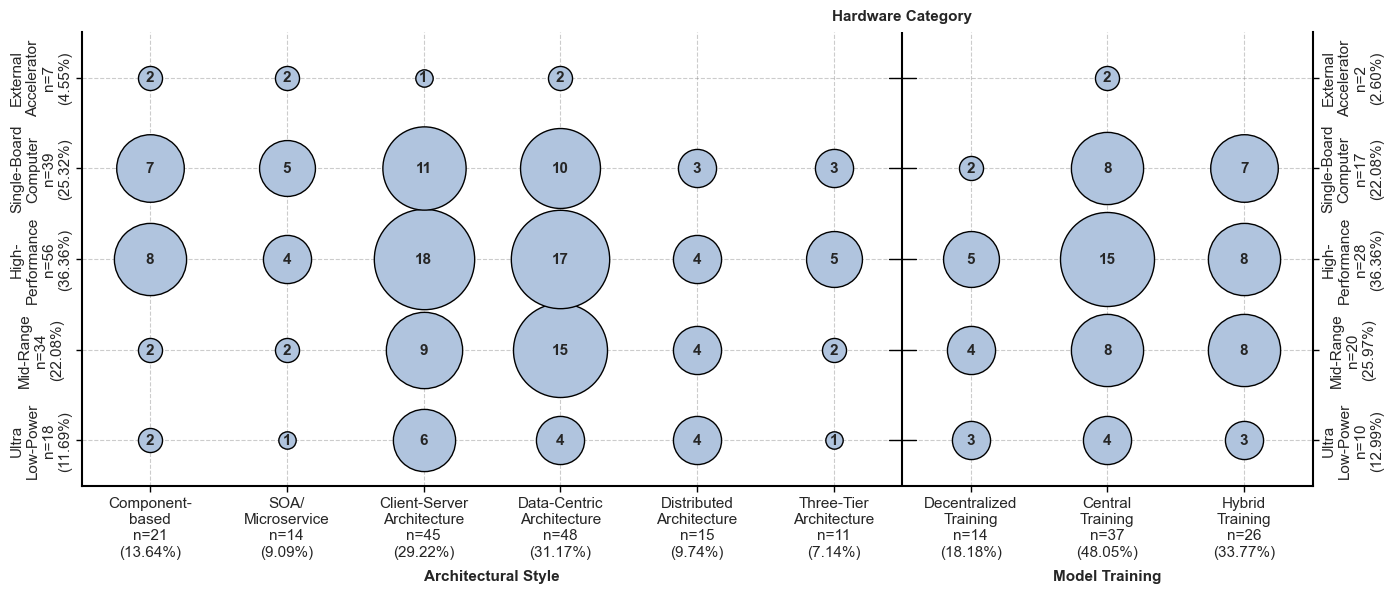

✓ Map 4 created


In [352]:
fig, ax = create_3d_systematic_map(
    df,
    'Architectural Style',
    'Model Training',
    'Hardware Category',
    'Systematic Map: Architectural Style + Model Training vs Hardware',
    figsize=(14, 6)
)
plt.show()
print("✓ Map 4 created")

## 12. Map 5 (3D): Architectural Style + Model Management vs Model Training

✓ 3D systematic map function defined


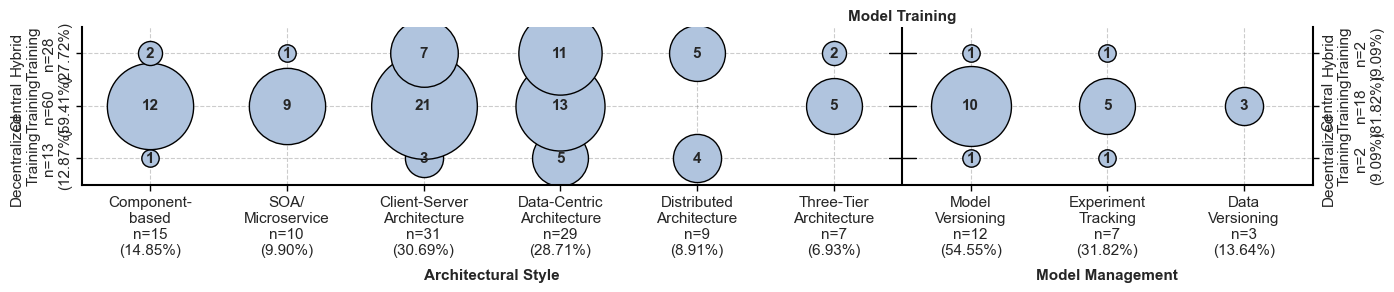

✓ Map 5 created


In [353]:
fig, ax = create_3d_systematic_map(
    df,
    'Architectural Style',
    'Model Management',
    'Model Training',
    'Systematic Map: Architectural Style + Model Management vs Model Training',
    figsize=(14, 3)
)
plt.show()
print("✓ Map 5 created")

## 13. Map 6 (3D): Model Management + Monitoring Metrics vs Model Learning

✓ 3D systematic map function defined


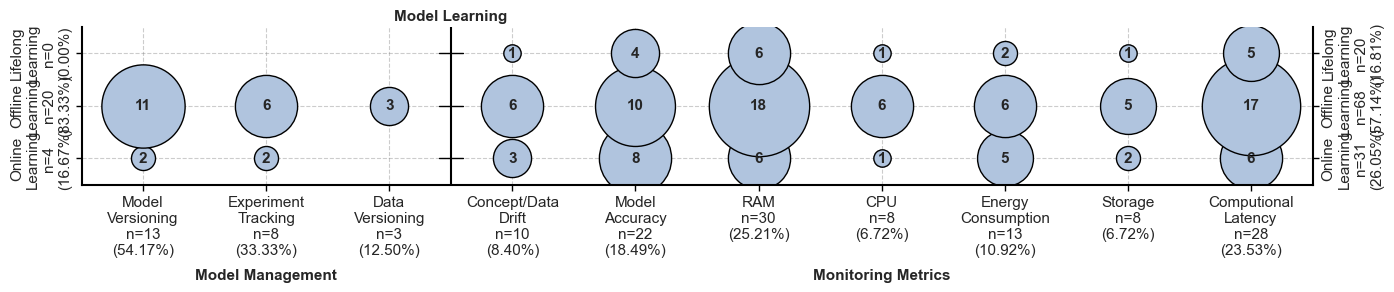

✓ Map 6 created


In [354]:
fig, ax = create_3d_systematic_map(
    df,
    'Model Management',
    'Monitoring Metrics',
    'Model Learning',
    'Systematic Map: Model Management + Monitoring Metrics vs Model Learning',
    figsize=(14, 3)
)
plt.show()
print("✓ Map 6 created")

## 14. Map 7 (3D): CI/CD + Model Optimization vs Model Training

✓ 3D systematic map function defined


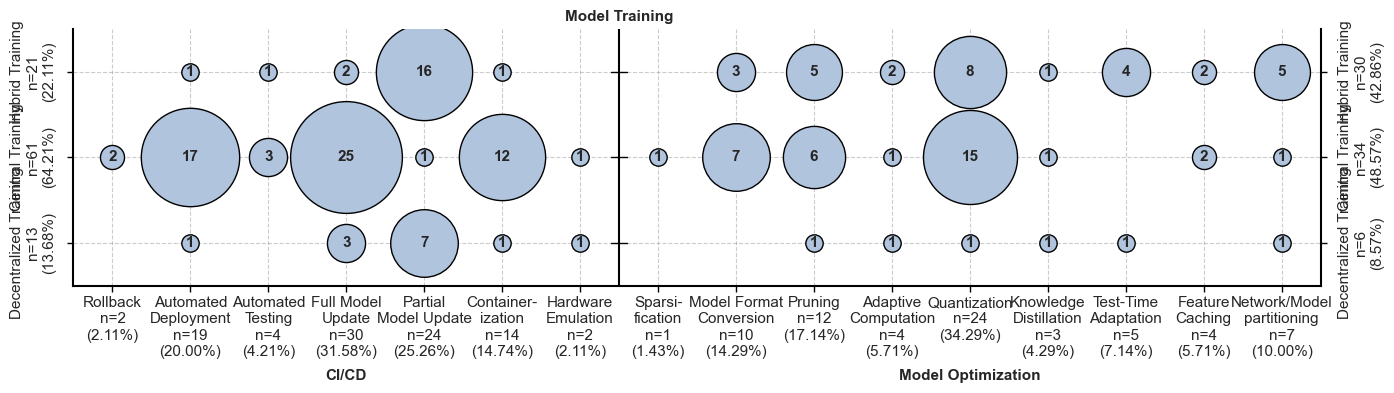

✓ Map 7 created


In [355]:
fig, ax = create_3d_systematic_map(
    df,
    'CI/CD',
    'Model Optimization',
    'Model Training',
    'Systematic Map: CI/CD + Model Optimization vs Model Training',
    wrap_y=False,
    wrap_max_len= 10,
    figsize=(14, 4)
)
plt.show()
print("✓ Map 7 created")

## 15. Export to PDF with Preview

This section regenerates all visualizations, shows a preview in the notebook, and exports them as PDF files.

In [ ]:
# Create output directory for PDFs
output_dir = Path('../data/cleaned_for_analysis/JSS-SLR/pdf_exports')
output_dir.mkdir(parents=True, exist_ok=True)

print(f"PDF Output directory: {output_dir}")
print("="*60)
print("Creating visualizations with preview and PDF export...")
print("="*60)

export_list = []

PDF Output directory: ..\data\cleaned_for_analysis\TSE-SLR\pdf_exports
Creating visualizations with preview and PDF export...


In [357]:
# Export Histogram 1 (stacked bars)
year_type_counts = df.groupby(['Year', 'Publication Type']).size().reset_index(name='Count')
years = sorted(year_type_counts['Year'].unique())
pub_types = sorted(year_type_counts['Publication Type'].unique())

# Create data matrix for stacked bars
data_matrix = np.zeros((len(pub_types), len(years)))
for i, pub_type in enumerate(pub_types):
    for j, year in enumerate(years):
        count = year_type_counts[
            (year_type_counts['Year'] == year) & 
            (year_type_counts['Publication Type'] == pub_type)
        ]['Count'].values
        data_matrix[i, j] = count[0] if len(count) > 0 else 0

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = current_palette['colors'][:len(pub_types)]

# Plot stacked bars
bottom = np.zeros(len(years))
for i, pub_type in enumerate(pub_types):
    ax.bar(years, data_matrix[i], bottom=bottom, label=escape_latex(pub_type),
           color=colors[i], edgecolor='black', linewidth=0.5)
    bottom += data_matrix[i]

# Add year totals at the top of each bar
for j, year in enumerate(years):
    total = int(bottom[j])
    ax.text(year, bottom[j] + 0.3, 
            str(total), 
            ha='center', va='bottom', 
            fontsize=10, color='black')

ax.set_xlabel('Year', fontweight='bold', fontsize=11)
ax.set_ylabel('Count', fontweight='bold', fontsize=11)
ax.legend(title=escape_latex('Publication Type'), frameon=True, loc='upper left', fontsize=11, title_fontsize=11)

# Y-axis: only integer values
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.grid(False)  # Disable all grid lines first
ax.grid(True, axis='y', alpha=0.4, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

# Remove all spines except bottom (x-axis)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['bottom'].set_color('black')

# Y-axis ticks: small black markers (must come AFTER hiding spines)
ax.tick_params(axis='y', labelsize=11, length=4, color='black', width=1, left=True, right=False)
ax.tick_params(axis='x', labelsize=11)  # X-axis tick labels

plt.tight_layout()
filename = output_dir / 'histogram_publication_frequency.pdf'
fig.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
plt.close()
export_list.append(filename.name)
print(f"✓ Exported: {filename.name}")

✓ Exported: histogram_publication_frequency.pdf


In [358]:
# Export Histogram 2
arch_stats = calculate_category_stats(df, 'Architectural Style')
arch_stats = arch_stats.sort_values('count', ascending=False)
fig, ax1 = plt.subplots(figsize=(7, 5))
x_pos = np.arange(len(arch_stats))

bars = ax1.bar(x_pos, arch_stats['count'], color='lightsteelblue', alpha=1,
               edgecolor='black', linewidth=0.5, label='Count')
ax1.set_xlabel('Architectural Style', fontweight='bold', fontsize=11)
ax1.set_ylabel('Count', fontweight='bold', fontsize=11)
ax1.set_xticks(x_pos)

# Create multi-line labels for x-axis
x_labels = []
for elem in arch_stats['element']:
    escaped = escape_latex(DISPLAY_NAMES.get(elem, elem))
    if len(escaped) > 11:
        words = escaped.split()
        if len(words) > 1:
            mid = len(words) // 2
            label = ' '.join(words[:mid]) + '\n' + ' '.join(words[mid:])
        elif '-' in escaped:
            label = escaped.replace('-', '-\n', 1)
        elif '/' in escaped:
            label = escaped.replace('/', '/\n', 1)
        else:
            label = escaped
    else:
        label = escaped
    x_labels.append(label)

ax1.set_xticklabels(x_labels, rotation=0, ha='center', fontsize=11)
ax1.tick_params(axis='y', labelsize=11, length=4, color='black', width=1, left=True, right=False)
ax1.tick_params(axis='x', labelsize=11)
ax1.grid(False)
ax1.grid(True, axis='y', alpha=0.4, linestyle='--', linewidth=0.8)
ax1.set_axisbelow(True)

# Add headroom for percentage labels above bars
ax1.set_ylim(0, arch_stats['count'].max() * 1.25)

# Annotate each bar with its percentage value
pct_sign = r'\%' if USE_LATEX else '%'
for bar, pct in zip(bars, arch_stats['percentage']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + ax1.get_ylim()[1] * 0.01,
        f"{pct:.2f}{pct_sign}",
        ha='center', va='bottom', fontsize=10, color='black'
    )

# Remove all spines except bottom (x-axis)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_linewidth(1.5)
ax1.spines['bottom'].set_color('black')

plt.tight_layout()
filename = output_dir / 'histogram_architectural_styles.pdf'
fig.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
plt.close()
print(f"✓ Exported: {filename.name}")
export_list.append(filename.name)


✓ Exported: histogram_architectural_styles.pdf


In [359]:
# Export Histogram 3
arch_stats = calculate_category_stats(df, 'CI/CD')
arch_stats = arch_stats.sort_values('count', ascending=True)  # ascending for barh (top = highest)
fig, ax1 = plt.subplots(figsize=(7, 5))

y_pos = np.arange(len(arch_stats))
bars = ax1.barh(y_pos, arch_stats['count'], color='lightsteelblue', alpha=1,
                edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Count', fontweight='bold', fontsize=11)
ax1.set_ylabel('CI/CD Tactics', fontweight='bold', fontsize=11)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([HISTOGRAM_DISPLAY_NAMES.get(elem, elem) for elem in arch_stats['element']], fontsize=11)

ax1.tick_params(axis='x', labelsize=11, length=4, color='black', width=1)
ax1.tick_params(axis='y', labelsize=11, length=0)
ax1.grid(False)
ax1.grid(True, axis='x', alpha=0.4, linestyle='--', linewidth=0.8)
ax1.set_axisbelow(True)

# X-axis: only integer values
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Add headroom for count labels at end of bars
ax1.set_xlim(0, arch_stats['count'].max() * 1.2)

# Annotate each bar with its count value
for bar, cnt in zip(bars, arch_stats['count']):
    ax1.text(
        bar.get_width() + ax1.get_xlim()[1] * 0.01,
        bar.get_y() + bar.get_height() / 2,
        str(int(cnt)),
        ha='left', va='center', fontsize=10, color='black'
    )

# Remove all spines except left (y-axis)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(1.5)
ax1.spines['left'].set_color('black')
ax1.spines['bottom'].set_visible(False)

plt.tight_layout()
filename = output_dir / 'histogram_ci-cd_tactics.pdf'
fig.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
plt.close()
print(f"✓ Exported: {filename.name}")
export_list.append(filename.name)



✓ Exported: histogram_ci-cd_tactics.pdf


In [360]:

# Export Histogram 4
arch_stats = calculate_category_stats(df, 'Model Optimization')
arch_stats = arch_stats.sort_values('count', ascending=True)  # ascending for barh (top = highest)
fig, ax1 = plt.subplots(figsize=(7, 5))

y_pos = np.arange(len(arch_stats))
bars = ax1.barh(y_pos, arch_stats['count'], color='lightsteelblue', alpha=1,
                edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Count', fontweight='bold', fontsize=11)
ax1.set_ylabel('Model Optimization Tactics', fontweight='bold', fontsize=11)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([HISTOGRAM_DISPLAY_NAMES.get(elem, elem) for elem in arch_stats['element']], fontsize=11)

ax1.tick_params(axis='x', labelsize=11, length=4, color='black', width=1)
ax1.tick_params(axis='y', labelsize=11, length=0)
ax1.grid(False)
ax1.grid(True, axis='x', alpha=0.4, linestyle='--', linewidth=0.8)
ax1.set_axisbelow(True)

# X-axis: only integer values
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Add headroom for count labels at end of bars
ax1.set_xlim(0, arch_stats['count'].max() * 1.2)

# Annotate each bar with its count value
for bar, cnt in zip(bars, arch_stats['count']):
    ax1.text(
        bar.get_width() + ax1.get_xlim()[1] * 0.01,
        bar.get_y() + bar.get_height() / 2,
        str(int(cnt)),
        ha='left', va='center', fontsize=10, color='black'
    )

# Remove all spines except left (y-axis)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(1.5)
ax1.spines['left'].set_color('black')
ax1.spines['bottom'].set_visible(False)

plt.tight_layout()
filename = output_dir / 'histogram_model-optimization_tactics.pdf'
fig.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
plt.close()
print(f"✓ Exported: {filename.name}")
export_list.append(filename.name)


✓ Exported: histogram_model-optimization_tactics.pdf



Creating: Classification Overview: Research Type vs Contribution Type
✓ 2D systematic map function defined


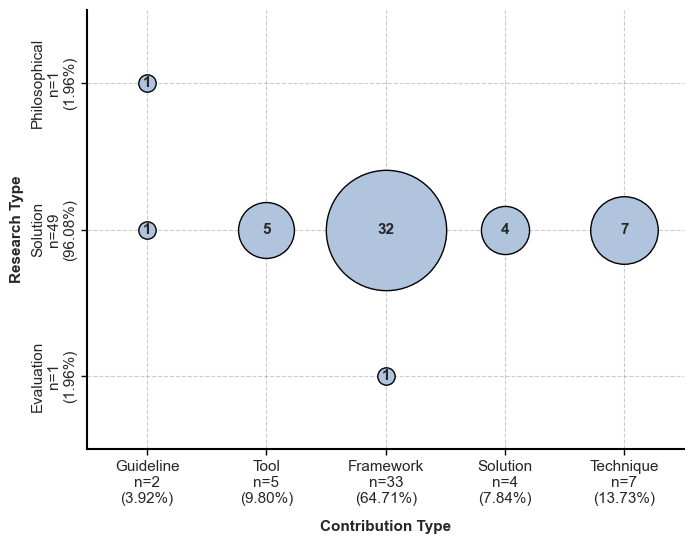

✓ Exported: map_2d_research_vs_contribution.pdf

Creating: Systematic Map: Model Learning vs Model Training
✓ 2D systematic map function defined


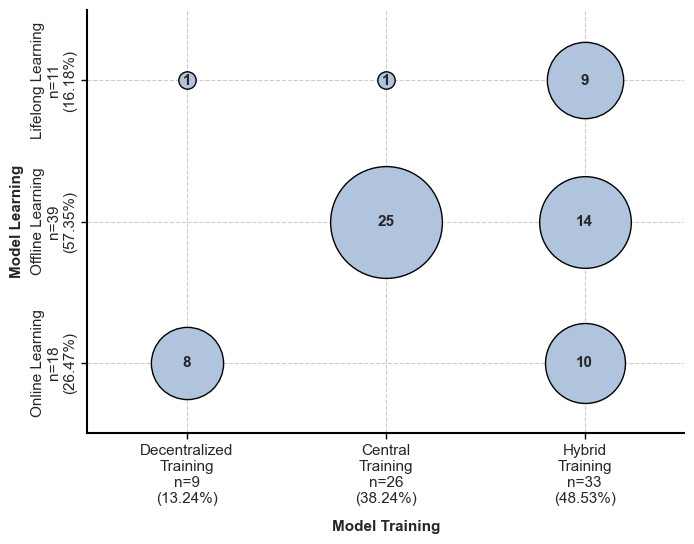

✓ Exported: map_2d_learning_vs_training.pdf

Creating: Systematic Map: Use Case vs Hardware Category
✓ 2D systematic map function defined


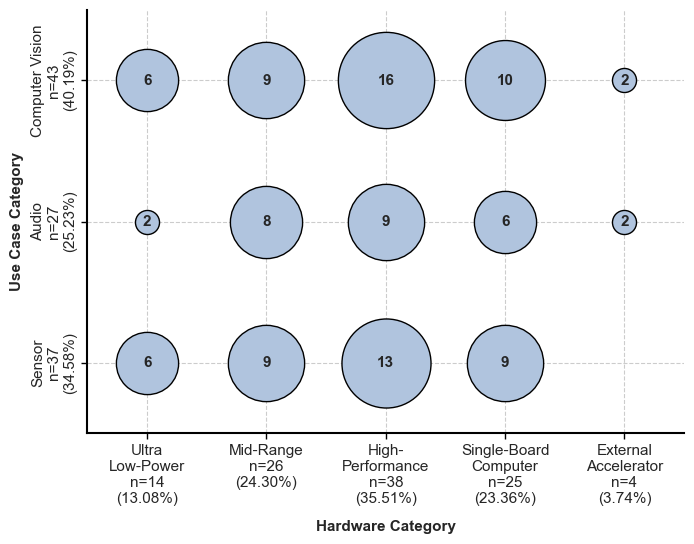

✓ Exported: map_2d_usecase_vs_hardware.pdf


In [361]:
# Export Maps 1-3 (2D)
maps_2d = [
    ('Contribution Type', 'Research Type', 'Classification Overview: Research Type vs Contribution Type',
     'map_2d_research_vs_contribution.pdf',
     {}),
    ('Model Training', 'Model Learning', 'Systematic Map: Model Learning vs Model Training',
     'map_2d_learning_vs_training.pdf',
     {'wrap_y':False}),
    ('Hardware Category', 'Use Case Category', 'Systematic Map: Use Case vs Hardware Category',
     'map_2d_usecase_vs_hardware.pdf',
     {'wrap_y':False}),
]

for x_cat, y_cat, title, fname, kwargs in maps_2d:
    print(f"\nCreating: {title}")
    fig, ax = create_2d_systematic_map(df, x_cat, y_cat, title, **kwargs)
    plt.show()  # Show preview
    filename = output_dir / fname
    fig.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
    plt.close()
    export_list.append(filename.name)
    print(f"✓ Exported: {filename.name}")



Creating: Systematic Map: Architectural Style + Model Training vs Hardware
✓ 3D systematic map function defined


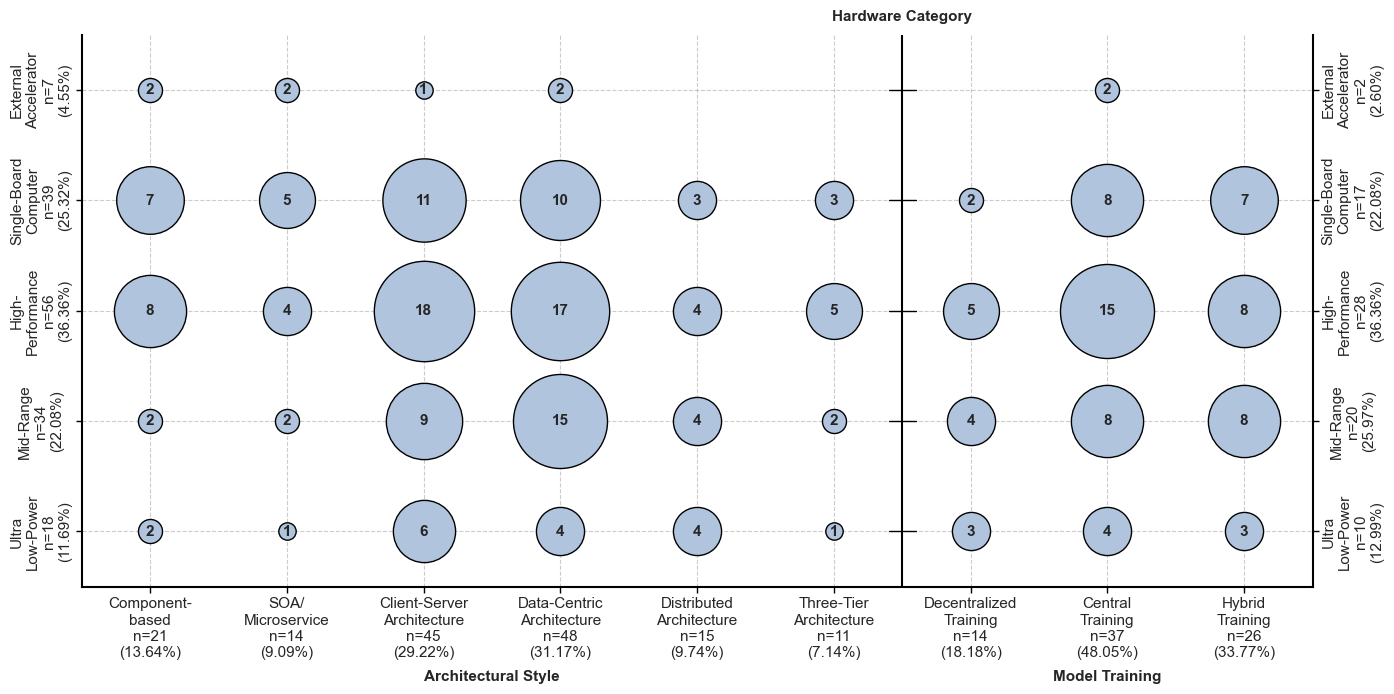

✓ Exported: map_3d_style_training_vs_hardware.pdf

Creating: Systematic Map: Architectural Style + Model Management vs Model Training
✓ 3D systematic map function defined


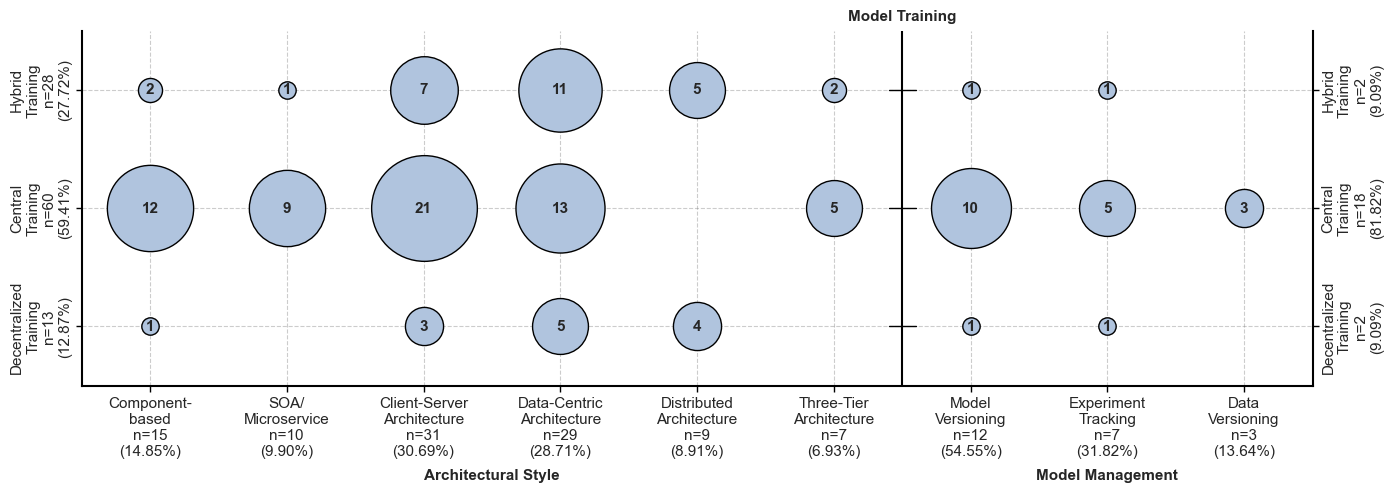

✓ Exported: map_3d_style_management_vs_training.pdf

Creating: Systematic Map: Model Management + Monitoring Metrics vs Model Learning
✓ 3D systematic map function defined


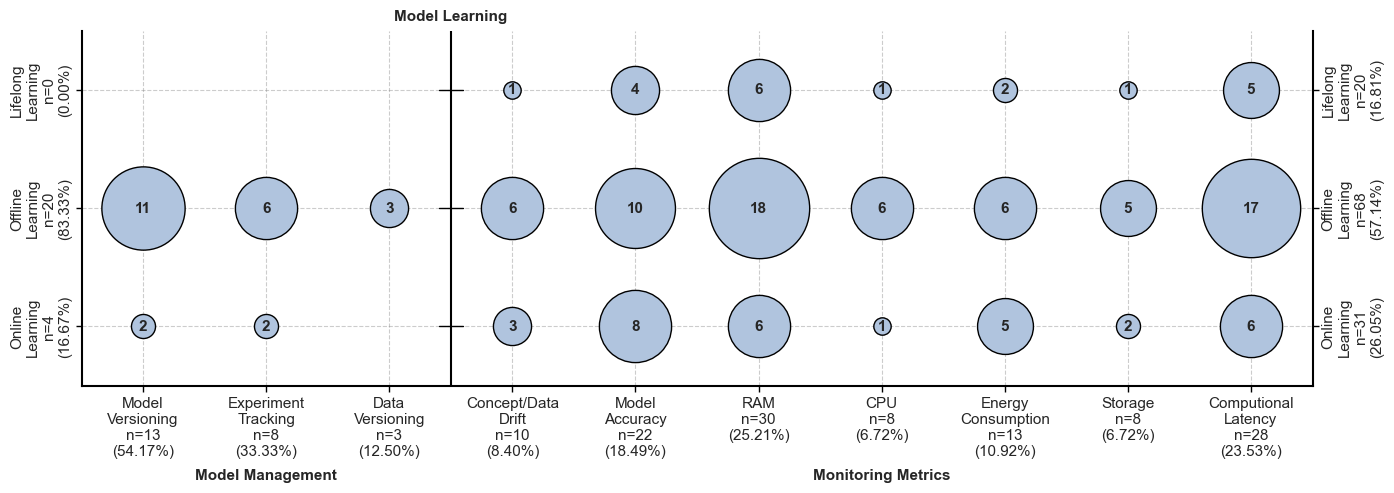

✓ Exported: map_3d_management_monitoring_vs_learning.pdf

Creating: Systematic Map: CI/CD + Model Optimization vs Model Training
✓ 3D systematic map function defined


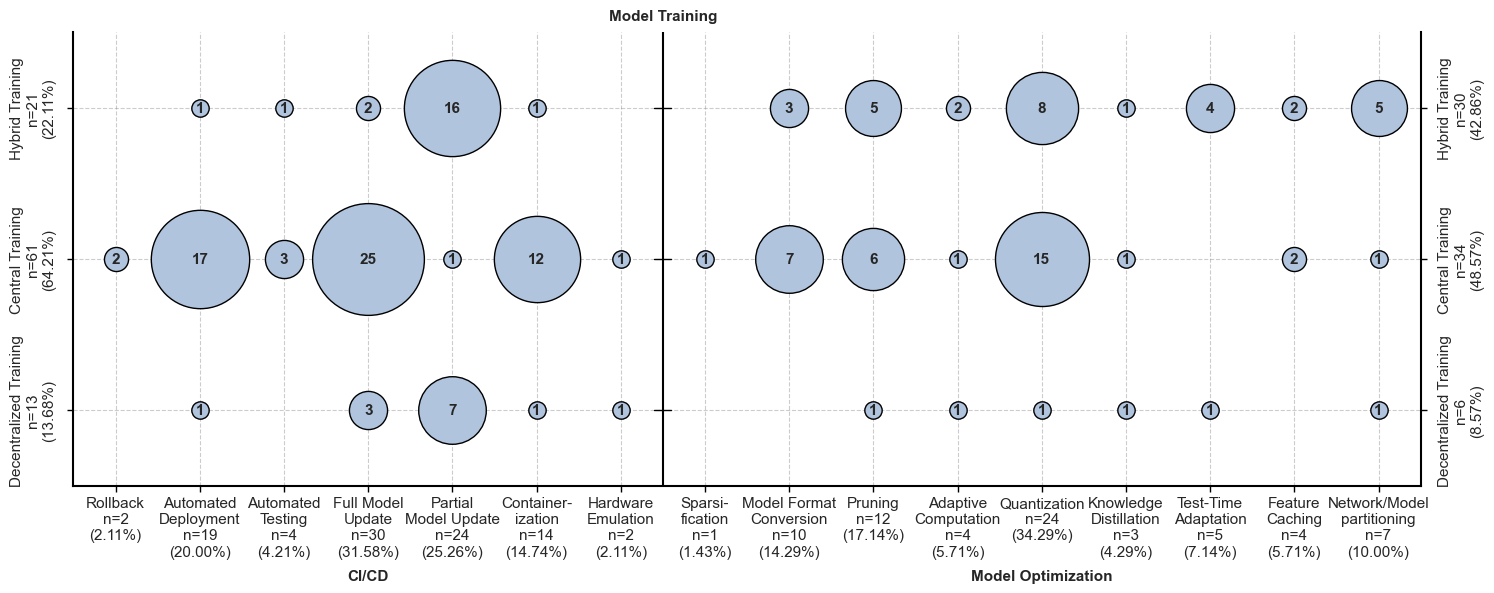

✓ Exported: map_3d_cicd_optimization_vs_training.pdf


In [362]:
# Export Maps 4-7 (3D)
maps_3d = [
    ('Architectural Style', 'Model Training', 'Hardware Category',
     'Systematic Map: Architectural Style + Model Training vs Hardware',
     'map_3d_style_training_vs_hardware.pdf',
     {'figsize': (14, 7)}),
    ('Architectural Style', 'Model Management', 'Model Training',
     'Systematic Map: Architectural Style + Model Management vs Model Training',
     'map_3d_style_management_vs_training.pdf',
     {'figsize': (14, 5)}),
    ('Model Management', 'Monitoring Metrics', 'Model Learning',
     'Systematic Map: Model Management + Monitoring Metrics vs Model Learning',
     'map_3d_management_monitoring_vs_learning.pdf',
     {'figsize': (14, 5)}),
    ('CI/CD', 'Model Optimization', 'Model Training',
     'Systematic Map: CI/CD + Model Optimization vs Model Training',
     'map_3d_cicd_optimization_vs_training.pdf',
     {'wrap_y': False,'wrap_max_len': 10,'figsize': (15, 6)}),
]

for x_left, x_right, y_cat, title, fname, kwargs in maps_3d:
    print(f"\nCreating: {title}")
    fig, ax = create_3d_systematic_map(df, x_left, x_right, y_cat, title, **kwargs)
    plt.show()  # Show preview
    filename = output_dir / fname
    fig.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
    plt.close()
    export_list.append(filename.name)
    print(f"✓ Exported: {filename.name}")


In [363]:
# Summary
print(f"\n{'='*60}")
print(f"Export complete! {len(export_list)} files created:")
print(f"{'='*60}")
for fname in export_list:
    print(f"  - {fname}")
print(f"\nLocation: {output_dir.absolute()}")


Export complete! 11 files created:
  - histogram_publication_frequency.pdf
  - histogram_architectural_styles.pdf
  - histogram_ci-cd_tactics.pdf
  - histogram_model-optimization_tactics.pdf
  - map_2d_research_vs_contribution.pdf
  - map_2d_learning_vs_training.pdf
  - map_2d_usecase_vs_hardware.pdf
  - map_3d_style_training_vs_hardware.pdf
  - map_3d_style_management_vs_training.pdf
  - map_3d_management_monitoring_vs_learning.pdf
  - map_3d_cicd_optimization_vs_training.pdf

Location: c:\Users\phili\Dropbox\01_Dev\Experimental-Data-Analysis\notebooks\..\data\cleaned_for_analysis\TSE-SLR\pdf_exports


## Summary

### Created Visualizations:

**Histograms:**
1. Publication Frequency per Year (grouped by publication type)
2. Architectural Style Frequency Distribution (dual y-axis: count + percentage)

**2D Systematic Maps:**
1. Research Type vs Contribution Type
2. Model Learning vs Model Training
3. Use Case Category vs Hardware Category

**3D Systematic Maps:**
4. Architectural Style (left) + Model Training (right) vs Hardware Category
5. Architectural Style (left) + Model Management (right) vs Model Training
6. Model Management (left) + Monitoring Metrics (right) vs Model Learning
7. CI/CD (left) + Model Optimization (right) vs Model Training

### Features:
- ✓ Direct PDF export (300 DPI)
- ✓ Preview before export
- ✓ Bubble sizing with ln-scaling
- ✓ Category statistics (n=X, Y%) annotations
- ✓ Dashed gridlines for category boundaries
- ✓ Intersection counts displayed in bubbles
- ✓ Multiple color palette options (Set2, tab10, Dark2)
- ✓ Publication-quality formatting

### Usage Notes:
- Change `PALETTE_CHOICE` in cell 5 to switch color schemes
- All PDF files are saved to `data/cleaned_for_analysis/JSS-SLR/pdf_exports/`
- 51 papers analyzed (IDs 1-54, excluding 23, 27, 41)
- Preview is shown in notebook before each export